[Dataset](https://www.kaggle.com/datasets/bytadit/ecommerce-order-dataset/data)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df_orders = pd.read_csv('df_Orders.csv')
df_orderitems = pd.read_csv('df_OrderItems.csv')
df_customer = pd.read_csv('df_Customers.csv')
df_products = pd.read_csv('df_Products.csv')
df_payments = pd.read_csv('df_Payments.csv')

### Проверка Orders

In [5]:
df_orders.shape

(89316, 7)

In [7]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18


In [8]:
df_orders.tail()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
89311,zlcLnXGgAabl,bfJtzkBGksdY,delivered,2018-08-19 17:25:36,2018-08-21 04:35:30,2018-08-30 14:47:46,2018-09-04
89312,IlTAoIkILwrq,4hjsCpj6FC7g,delivered,2017-12-15 11:20:27,2017-12-16 02:37:32,2017-12-20 19:23:40,2018-01-04
89313,uA6oXfftGVmT,DLn56oKHl9bv,delivered,2018-07-24 06:39:14,2018-07-24 11:20:39,2018-07-27 01:41:40,2018-08-01
89314,v3QtU6xlGDJp,auSfRYUQUOIq,delivered,2018-08-11 08:04:22,2018-08-11 08:24:40,2018-08-14 21:43:51,2018-08-17
89315,Xo1fqyXOC6CR,rhevVNXYJnEs,delivered,2018-06-09 21:46:58,2018-06-09 22:19:00,2018-06-14 15:03:46,2018-07-05


In [9]:
df_orders.sample(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date
83228,6AHNlhtEaxW2,7LWf0iN4M1Lk,delivered,2017-09-15 00:36:44,2017-09-15 00:50:11,2017-09-26 18:26:51,2017-10-16
29777,y1nnitNpmi94,xRiTiWA3Iuy4,delivered,2018-07-21 22:35:28,2018-07-26 23:32:14,2018-08-02 21:18:40,2018-08-10
26707,y3qkMdv5rffg,uYCVz4FcQWhV,delivered,2018-02-19 15:33:55,2018-02-19 16:35:26,2018-03-05 20:34:32,2018-03-19
63790,r5uaYNraWYyq,m0oWSXUZreew,delivered,2017-02-25 09:21:20,2017-02-25 09:30:11,2017-03-08 12:59:03,2017-03-23
38612,Px1NoNWnwkXF,8cKCscw9Tyvx,delivered,2018-05-02 21:09:08,2018-05-02 21:35:30,2018-05-08 19:18:48,2018-05-25
26718,AKPwqeOiAp2H,oa9XcbQNa8vL,delivered,2018-05-22 21:06:32,2018-05-22 21:18:33,2018-05-28 19:12:57,2018-06-07
82614,xPP9uYn5dKKF,z79Mg8d6UXW3,delivered,2017-09-24 19:21:57,2017-09-24 19:30:23,2017-10-03 18:15:59,2017-10-19
10528,uMMCeUU9oNYT,8SYPafpSOcXG,delivered,2018-03-25 17:23:39,2018-03-25 17:35:24,2018-04-17 18:07:55,2018-04-20
56999,J3daQq4kW3CW,ZaiqhSnBHJkv,delivered,2018-03-05 10:51:31,2018-03-05 11:15:39,2018-03-10 00:52:20,2018-03-23
46738,CumWnyt1w536,JMWa7IYGqgV4,delivered,2018-08-08 14:40:51,2018-08-08 14:50:19,2018-08-15 17:46:51,2018-08-22


In [10]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_timestamp',
       'order_estimated_delivery_date'],
      dtype='str')

In [11]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       89316 non-null  str  
 1   customer_id                    89316 non-null  str  
 2   order_status                   89316 non-null  str  
 3   order_purchase_timestamp       89316 non-null  str  
 4   order_approved_at              89307 non-null  str  
 5   order_delivered_timestamp      87427 non-null  str  
 6   order_estimated_delivery_date  89316 non-null  str  
dtypes: str(7)
memory usage: 4.8 MB


In [12]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

df_orders[date_cols] = df_orders[date_cols].apply(pd.to_datetime)

In [13]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       89316 non-null  str           
 1   customer_id                    89316 non-null  str           
 2   order_status                   89316 non-null  str           
 3   order_purchase_timestamp       89316 non-null  datetime64[us]
 4   order_approved_at              89307 non-null  datetime64[us]
 5   order_delivered_timestamp      87427 non-null  datetime64[us]
 6   order_estimated_delivery_date  89316 non-null  datetime64[us]
dtypes: datetime64[us](4), str(3)
memory usage: 4.8 MB


In [15]:
df_orders.nunique()

order_id                         89316
customer_id                      89316
order_status                         7
order_purchase_timestamp         72775
order_approved_at                68215
order_delivered_timestamp        71143
order_estimated_delivery_date      444
dtype: int64

In [18]:
df_orders.duplicated().sum()

np.int64(0)

In [14]:
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   9
order_delivered_timestamp        1889
order_estimated_delivery_date       0
dtype: int64

In [31]:
df_orders['order_id'].value_counts()

order_id
Axfy13Hk4PIk    1
v6px92oS8cLG    1
Ulpf9skrhjfm    1
bwJVWupf2keN    1
Dd0QnrMk9Cj5    1
               ..
zlcLnXGgAabl    1
IlTAoIkILwrq    1
uA6oXfftGVmT    1
v3QtU6xlGDJp    1
Xo1fqyXOC6CR    1
Name: count, Length: 89316, dtype: int64

In [32]:
df_orders['order_id'].value_counts().loc[lambda x: x > 1]

Series([], Name: count, dtype: int64)

In [45]:
df_orders['order_status'].value_counts()

order_status
delivered      87428
shipped          936
canceled         409
processing       273
invoiced         266
unavailable        2
approved           2
Name: count, dtype: int64

In [48]:
df_orders['order_status'].value_counts(normalize=True) * 100

order_status
delivered      97.886157
shipped         1.047965
canceled        0.457925
processing      0.305656
invoiced        0.297819
unavailable     0.002239
approved        0.002239
Name: proportion, dtype: float64

In [54]:
status_stats = pd.concat(
    [df_orders['order_status'].value_counts(),
     (df_orders['order_status'].value_counts(normalize=True) * 100).round(2)],
     axis=1
)
status_stats.columns=['count', 'share_pct']
status_stats

,count,share_pct
order_status,,
delivered,87428,97.89
shipped,936,1.05
canceled,409,0.46
processing,273,0.31
invoiced,266,0.30
unavailable,2,0.00
approved,2,0.00


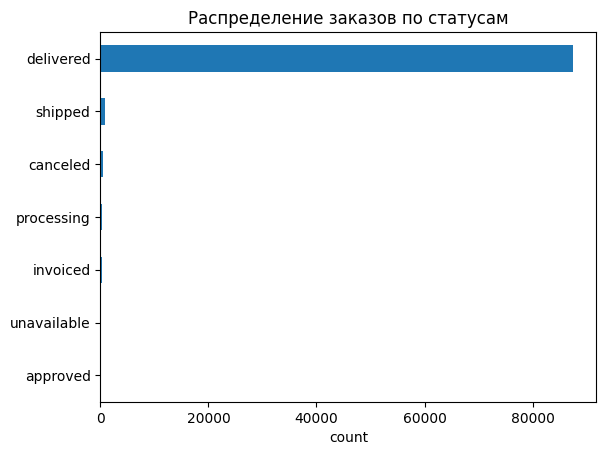

In [64]:
status_counts = df_orders['order_status'].value_counts().sort_values(ascending=True)

status_counts.plot(kind='barh', ylabel='')
plt.xlabel('count')
# plt.ylabel('order_status')
plt.title('Распределение заказов по статусам')
plt.show()

In [75]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_timestamp',
    'order_estimated_delivery_date'
]

missing_dates_cnt = df_orders[date_cols].isna().sum()
missing_dates_pct = (df_orders[date_cols].isna().mean() * 100).round(2)

missing_dates_stats = pd.concat([missing_dates_cnt, missing_dates_pct], axis=1)
missing_dates_stats.columns = ['missing_count', 'missing_pct']
missing_dates_stats

,missing_count,missing_pct
order_purchase_timestamp,0,0.00
order_approved_at,9,0.01
order_delivered_timestamp,1889,2.11
order_estimated_delivery_date,0,0.00


In [76]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_timestamp',
       'order_estimated_delivery_date'],
      dtype='str')

In [81]:
df_orders['purchase_to_approved'] = (
    df_orders['order_approved_at'] - df_orders['order_purchase_timestamp']
)

df_orders['approved_to_delivered'] = (
    df_orders['order_delivered_timestamp'] - df_orders['order_approved_at']
)

df_orders['purchase_to_estimated'] = (
    df_orders['order_estimated_delivery_date'] - df_orders['order_purchase_timestamp']
)

df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,purchase_to_approved,approved_to_delivered,purchase_to_estimated
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0 days 00:16:19,4 days 03:05:39,17 days 05:02:06
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0 days 00:39:49,13 days 00:31:02,33 days 02:19:29
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0 days 23:56:04,9 days 09:14:15,19 days 07:40:29
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0 days 00:10:47,9 days 01:48:35,31 days 05:55:31
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0 days 00:47:27,14 days 01:51:18,26 days 07:15:56


In [82]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       89316 non-null  str            
 1   customer_id                    89316 non-null  str            
 2   order_status                   89316 non-null  str            
 3   order_purchase_timestamp       89316 non-null  datetime64[us] 
 4   order_approved_at              89307 non-null  datetime64[us] 
 5   order_delivered_timestamp      87427 non-null  datetime64[us] 
 6   order_estimated_delivery_date  89316 non-null  datetime64[us] 
 7   purchase_to_approved           89307 non-null  timedelta64[us]
 8   approved_to_delivered          87418 non-null  timedelta64[us]
 9   purchase_to_estimated          89316 non-null  timedelta64[us]
dtypes: datetime64[us](4), str(3), timedelta64[us](3)
memory usage: 6.8 MB


In [85]:
df_orders['purchase_to_approved_days'] = (
    df_orders['purchase_to_approved'] / np.timedelta64(1, 'D')
)

df_orders['approved_to_delivered_days'] = (
    df_orders['approved_to_delivered'] / np.timedelta64(1, 'D')
)

df_orders['purchase_to_estimated_days'] = (
    df_orders['purchase_to_estimated'] / np.timedelta64(1, 'D')
)

df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,purchase_to_approved,approved_to_delivered,purchase_to_estimated,purchase_to_approved_days,approved_to_delivered_days,purchase_to_estimated_days
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0 days 00:16:19,4 days 03:05:39,17 days 05:02:06,0.011331,4.128924,17.209792
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0 days 00:39:49,13 days 00:31:02,33 days 02:19:29,0.027650,13.021551,33.096863
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0 days 23:56:04,9 days 09:14:15,19 days 07:40:29,0.997269,9.384896,19.319780
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0 days 00:10:47,9 days 01:48:35,31 days 05:55:31,0.007488,9.075405,31.246887
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0 days 00:47:27,14 days 01:51:18,26 days 07:15:56,0.032951,14.077292,26.302731


In [87]:
cols_durations = [
    'purchase_to_approved_days',
    'approved_to_delivered_days',
    'purchase_to_estimated_days'
]

df_orders[cols_durations].describe()

,purchase_to_approved_days,approved_to_delivered_days,purchase_to_estimated_days
count,89307.000000,87418.000000,89316.000000
mean,0.434641,12.002213,23.894828
std,0.920866,9.237657,8.866609
min,0.000000,-6.989653,2.008009
25%,0.008970,6.290000,18.433970
50%,0.014363,9.821933,23.270347
75%,0.619716,15.005859,28.507234
max,60.452766,208.500972,149.592280


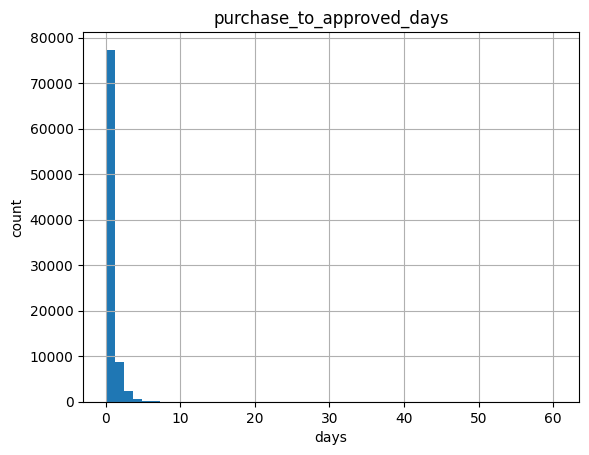

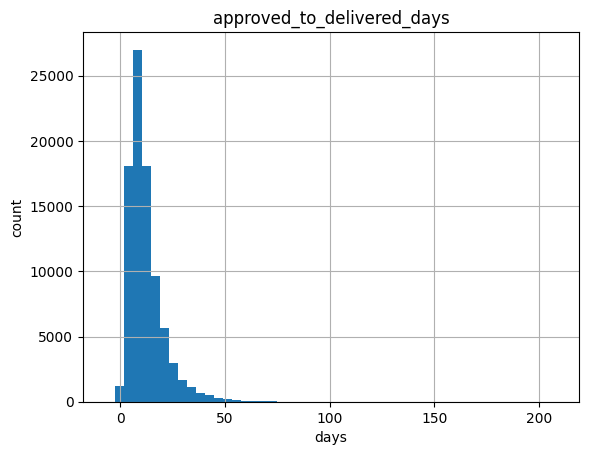

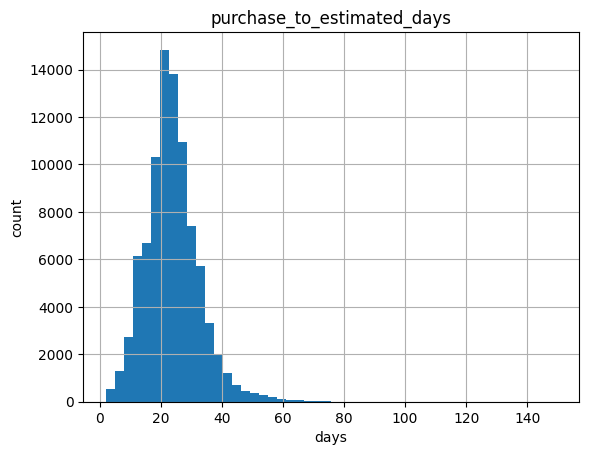

In [88]:
for col in cols_durations:
    df_orders[col].hist(bins=50)
    plt.title(col)
    plt.xlabel('days')
    plt.ylabel('count')
    plt.show()

In [92]:
neg_purchase_to_approved = (df_orders['purchase_to_approved_days'] < 0).sum()
neg_approved_to_delivered = (df_orders['approved_to_delivered_days'] < 0).sum()
neg_purchase_to_estimated = (df_orders['purchase_to_estimated_days'] < 0).sum()

In [93]:
neg_purchase_to_approved

np.int64(0)

In [94]:
neg_approved_to_delivered

np.int64(53)

In [95]:
neg_purchase_to_estimated

np.int64(0)

In [91]:
df_orders[df_orders['approved_to_delivered_days'] < 0][
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_timestamp',
        'approved_to_delivered_days'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,approved_to_delivered_days
732,qf88tnNyUpRx,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-15 14:56:43,-5.041505
2734,X7BdF882u7jZ,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-15 14:56:43,-5.041505
3311,nFPgCdm662nu,delivered,2018-07-24 11:32:11,2018-07-29 23:30:52,2018-07-27 18:55:57,-2.190914
5035,18BVSbwrvOLi,delivered,2017-06-26 12:23:32,2017-07-05 17:09:11,2017-07-03 17:53:29,-1.969236
5550,TkUmHDHxzRRF,delivered,2018-04-22 21:15:32,2018-04-24 19:24:43,2018-04-24 15:32:26,-0.161308


Пороги "аномальности" данных:
* для purchase_to_approved_days: аномально всё, что > 7 дней;
* для approved_to_delivered_days: аномально всё, что > 60 дней;
* для purchase_to_estimated_days: аномально всё, что > 90 дней (учитывая максимум ~150).

In [96]:
too_long_purchase_to_approved = (df_orders['purchase_to_approved_days'] > 7).sum()
too_long_approved_to_delivered = (df_orders['approved_to_delivered_days'] > 60).sum()
too_long_purchase_to_estimated = (df_orders['purchase_to_estimated_days'] > 90).sum()

In [97]:
too_long_purchase_to_approved

np.int64(69)

In [100]:
df_orders[df_orders['purchase_to_approved_days'] > 7][
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_timestamp',
        'approved_to_delivered_days'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,approved_to_delivered_days
583,1pmrI7xypD8L,delivered,2018-02-09 07:25:50,2018-02-16 07:50:26,2018-03-20 09:48:34,32.082037
656,n6dwwBlgVTuA,delivered,2018-01-20 14:24:50,2018-02-20 11:51:27,2018-03-02 22:37:49,10.448866
732,qf88tnNyUpRx,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-15 14:56:43,-5.041505
1442,s4nmQdphjmsG,delivered,2017-04-06 19:52:25,2017-04-17 08:50:17,2017-05-10 14:46:53,23.247639
2734,X7BdF882u7jZ,delivered,2018-08-09 20:45:10,2018-08-20 15:56:29,2018-08-15 14:56:43,-5.041505


In [98]:
too_long_approved_to_delivered

np.int64(250)

In [101]:
df_orders[df_orders['approved_to_delivered_days'] > 60][
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_timestamp',
        'approved_to_delivered_days'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,approved_to_delivered_days
384,FkANVps9FhLR,delivered,2018-01-08 16:02:04,2018-01-09 07:25:32,2018-04-03 17:38:54,84.425949
555,gtrzn1LyN7dM,delivered,2017-03-31 10:53:45,2017-04-04 06:05:09,2017-06-14 13:06:39,71.292708
571,pWRjBubXBYdq,delivered,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-09-19 14:36:39,208.500972
772,1E3iD0TBYiQv,delivered,2017-03-16 11:36:00,2017-03-16 11:36:00,2017-09-19 16:28:58,187.203449
1202,A3vUK2CgNZYI,delivered,2018-02-03 15:48:24,2018-02-03 16:10:36,2018-06-13 15:57:49,129.991123


In [99]:
too_long_purchase_to_estimated

np.int64(18)

In [102]:
df_orders[df_orders['purchase_to_estimated_days'] > 90][
    [
        'order_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_timestamp',
        'approved_to_delivered_days'
    ]
].head()

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,approved_to_delivered_days
7390,8s4BWE1S36x3,delivered,2017-10-27 17:03:40,2017-10-30 15:31:19,2017-11-25 13:12:08,25.903345
19610,BXlHv0L868zk,delivered,2017-03-23 17:36:38,2017-03-24 17:45:13,2017-05-18 12:24:25,54.777222
20243,ye1XSEmG9Ub8,shipped,2017-03-14 19:23:22,2017-03-14 19:23:22,NaT,NaN
20498,IdmJMX3QQj4O,processing,2017-03-30 15:23:23,2017-03-30 15:35:11,NaT,NaN
21858,QLPhYjdpFIXY,delivered,2017-05-23 22:28:36,2017-05-24 22:35:08,2017-06-09 13:35:54,15.625532


In [106]:
anomaly_purchase_to_approved = (
    (df_orders['purchase_to_approved_days'] < 0) |
    (df_orders['purchase_to_approved_days'] > 7)
)

anomaly_approved_to_delivered = (
    (df_orders['approved_to_delivered_days'] < 0) |
    (df_orders['approved_to_delivered_days'] > 60)
)

anomaly_purchase_to_estimated = (
    (df_orders['purchase_to_estimated_days'] < 0) |
    (df_orders['purchase_to_estimated_days'] > 90)
)

df_orders['is_anomalous'] = (
    anomaly_purchase_to_approved |
    anomaly_approved_to_delivered |
    anomaly_purchase_to_estimated
)

In [107]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_timestamp,order_estimated_delivery_date,purchase_to_approved,approved_to_delivered,purchase_to_estimated,purchase_to_approved_days,approved_to_delivered_days,purchase_to_estimated_days,is_anomalous
0,Axfy13Hk4PIk,hCT0x9JiGXBQ,delivered,2017-10-22 18:57:54,2017-10-22 19:14:13,2017-10-26 22:19:52,2017-11-09,0 days 00:16:19,4 days 03:05:39,17 days 05:02:06,0.011331,4.128924,17.209792,False
1,v6px92oS8cLG,PxA7fv9spyhx,delivered,2018-06-20 21:40:31,2018-06-20 22:20:20,2018-07-03 22:51:22,2018-07-24,0 days 00:39:49,13 days 00:31:02,33 days 02:19:29,0.027650,13.021551,33.096863,False
2,Ulpf9skrhjfm,g3nXeJkGI0Qw,delivered,2018-02-16 16:19:31,2018-02-17 16:15:35,2018-02-27 01:29:50,2018-03-08,0 days 23:56:04,9 days 09:14:15,19 days 07:40:29,0.997269,9.384896,19.319780,False
3,bwJVWupf2keN,EOEsCQ6QlpIg,delivered,2018-08-18 18:04:29,2018-08-18 18:15:16,2018-08-27 20:03:51,2018-09-19,0 days 00:10:47,9 days 01:48:35,31 days 05:55:31,0.007488,9.075405,31.246887,False
4,Dd0QnrMk9Cj5,mVz5LO2Vd6cL,delivered,2017-12-22 16:44:04,2017-12-22 17:31:31,2018-01-05 19:22:49,2018-01-18,0 days 00:47:27,14 days 01:51:18,26 days 07:15:56,0.032951,14.077292,26.302731,False


In [108]:
total_orders = len(df_orders)

normal_orders = (~df_orders['is_anomalous']).sum()
anomalous_orders = df_orders['is_anomalous'].sum()

summary = pd.DataFrame(
    {
        'orders_count': [total_orders, normal_orders, anomalous_orders],
    },
    index=['total', 'normal', 'anomalous']
)

summary['orders_pct'] = (summary['orders_count'] / total_orders * 100).round(2)
summary


,orders_count,orders_pct
total,89316,100.00
normal,88938,99.58
anomalous,378,0.42


In [ ]:
neg_any = (
    (df_orders['purchase_to_approved_days'] < 0) |
    (df_orders['approved_to_delivered_days'] < 0) |
    (df_orders['purchase_to_estimated_days'] < 0)
)

negative_orders = neg_any.sum()

total_orders = len(df_orders)

negative_orders = neg_any.sum()

normal_orders = ((~df_orders['is_anomalous']) & (~neg_any)).sum()

anomalous_orders = df_orders['is_anomalous'].sum()

summary = pd.DataFrame(
    {
        'orders_count': [
            total_orders,
            normal_orders,
            anomalous_orders,
            negative_orders
        ],
    },
    index=['total', 'normal', 'anomalous', 'negative']
)

summary['orders_pct'] = (summary['orders_count'] / total_orders * 100).round(2)
summary


,orders_count,orders_pct
total,89316,100.00
normal,88938,99.58
anomalous,336,0.38
negative,53,0.06


: 